# Setting up Mixed Precision Training:

In [1]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy= "mixed_float16")

# Importing Necessary Libraries:

In [52]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, TextVectorization, Embedding, GlobalMaxPool1D, LSTM, GRU, Conv1D, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

from sklearn.model_selection import train_test_split


# Importing and Exploring The Data:

In [3]:
df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
# Viewing 10 Random Reviews:
start_index = random.randint(0, len(df)-10)
for row in df[start_index : start_index+10].itertuples():
  _,text, label = row
  print(f"Label: {label}")
  print(f"Review: {text}\n")

Label: negative
Review: Two years after this short, the last "Our Gang" short was made. After seeing this, you wonder how it even lasted that much longer. The quality of "Our Gang" nosedived soon after moving from Hal Roach to MGM, and this short is a perfect example. The gags are all very unfunny and Froggy's last line of this being the happiest day of his life paints a bad picture in your mind of what it's like for him the rest of the time. A very poor example of film making.

Label: negative
Review: I am at a loss to find the words to express how bad I thought this film was. The initial precept was promising, but in all respects afterwards it was totally awful. Let's run through the main points. Plot - good initial idea but truly terrible development. There were many points when I thought "no, nobody would do something that stupid". The ending was amazingly anticlimactic. Characterisation - all of the characters were either completely bland or grotesque caricatures. I keep trying to

In [7]:
# Removing html tags from Data:
df["review"] = df["review"].replace({'<.*?>': ''}, regex = True)

In [8]:
# Viewing 10 Random Reviews:
start_index = random.randint(0, len(df)-10)
for row in df[start_index : start_index+10].itertuples():
  _,text, label = row
  print(f"Label: {label}")
  print(f"Review: {text}\n")

Label: negative
Review: Oliver Hardy awakens with a hangover and soon learns that his uncle is coming to see Ollie's new wife and baby. The problem is, they don't exist--Ollie apparently made them up! So, it's up to him and his pal to locate a lady with a baby who will agree to pose as his family.This isn't a particularly unique story idea, as I've seen at least a couple other silent shorts with this exact plot. The best of these was Bobby Vernon's DON'T KID ME. It is much better than ONE TOO MANY--probably much of this was due to it being made a decade later--when comedy became a bit more sophisticated and relied less on pointless slapstick. Now I am not against physical comedy, but in some slapstick films, people starting shooting guns wildly, kick and strangle each other, etc. with little provocation. Sadly, at the end of ONE TOO MANY, that's exactly what they do. None of it makes sense and it was as if they'd just run out of story ideas.Overall, not exactly a milestone in entertain

# Train Test Split:

In [9]:
# Converting Sentimnet to Numerical Data:
df["sentiment"]= df["sentiment"].map({"positive" : 1, "negative" : 0})

In [10]:
train_reviews, test_reviews, train_labels, test_labels = train_test_split(df["review"].to_numpy(),
                                                                          df["sentiment"].to_numpy(),
                                                                          test_size= 0.2,
                                                                          random_state= 42)

In [11]:
train_reviews.shape, test_reviews.shape, train_labels.shape, test_labels.shape

((40000,), (10000,), (40000,), (10000,))

In [12]:
train_reviews[0], train_labels[0]

('That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s the hope. Next time, hi

# Text Vectorization:

In [13]:
# Finding Average Length of Reviews (Number of Words):
len(train_reviews[0])

2292

In [14]:
train_reviews[0].split()

["That's",
 'what',
 'I',
 'kept',
 'asking',
 'myself',
 'during',
 'the',
 'many',
 'fights,',
 'screaming',
 'matches,',
 'swearing',
 'and',
 'general',
 'mayhem',
 'that',
 'permeate',
 'the',
 '84',
 'minutes.',
 'The',
 'comparisons',
 'also',
 'stand',
 'up',
 'when',
 'you',
 'think',
 'of',
 'the',
 'one-dimensional',
 'characters,',
 'who',
 'have',
 'so',
 'little',
 'depth',
 'that',
 'it',
 'is',
 'virtually',
 'impossible',
 'to',
 'care',
 'what',
 'happens',
 'to',
 'them.',
 'They',
 'are',
 'just',
 'badly',
 'written',
 'cyphers',
 'for',
 'the',
 'director',
 'to',
 'hang',
 'his',
 'multicultural',
 'beliefs',
 'on,',
 'a',
 'topic',
 'that',
 'has',
 'been',
 'done',
 'much',
 'better',
 'in',
 'other',
 'dramas',
 'both',
 'on',
 'TV',
 'and',
 'the',
 'cinema.I',
 'must',
 'confess,',
 "I'm",
 'not',
 'really',
 'one',
 'for',
 'spotting',
 'bad',
 'performances',
 'during',
 'a',
 'film,',
 'but',
 'it',
 'must',
 'be',
 'said',
 'that',
 'Nichola',
 'Burley',

In [15]:
len(train_reviews[0].split())

394

In [16]:
avg_len= []
for review in train_reviews:
  avg_len.append(len(review.split()))

In [17]:
avg_len = np.mean(avg_len)

In [18]:
avg_len

226.9529

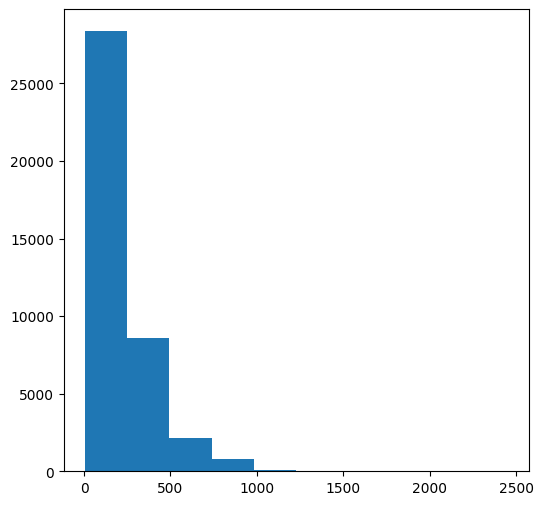

In [19]:
# Distribution of Review Lengths:
plt.figure(figsize= (6,6))
plt.hist([len(i.split()) for i in train_reviews])
plt.show()

In [20]:
# Finding Review Length that Covers 95% of Reviews:
np.percentile([len(i.split()) for i in train_reviews], 95)

579.0

In [21]:
# Creating Token Vectorizer:
token_vect = TextVectorization(max_tokens= 10000,
                               output_sequence_length= 579,
                               output_mode= "int")

In [22]:
# Fitting Token Vectorizer on Training Data:
token_vect.adapt(train_reviews)

In [23]:
# Checking Token Vectorizer on Random Review:
random_review = random.choice(train_reviews)
print(f"Original Review:\n{random_review}\n")
print(f"Review after Token Vectorization:\n {token_vect([random_review])}")

Original Review:
For years I remember reading about this show "Trouble With Tracy" in the TV Guide. CFTO-TV Toronto every Saturday morning at 6 am! I lived about a two-hour drive north of Toronto and we couldn't get CFTO, but you know how it is - we always want what we can't have.Well, I knew what I wanted and what I wanted was to see what this "Trouble With Tracy" was all about. Did it have a beautiful girl in the starring role? Was there nudity? Was there suspense? Was it a comedy? It would've been fine if there was some promotion of the show. At least I could've known what I was missing. But, NO! The mystery drove me bonkers, until CTV affiliate CKCO built a re-transmitter in Wiarton, Ontario and began to broadcast "Trouble With Tracy" at the same time as CFTO....Saturday mornings at 6 am!! One Saturday morning I got up and turned the TV on at 5:59 and at last I got to see what "The Trouble With Tracy" was. Yes, the "Trouble With Tracy" was that it was Canadian content and stuck in 

In [24]:
# Number of Words in Vocabulary of Token Vectorizer:
len(token_vect.get_vocabulary())

10000

In [25]:
token_vect.get_vocabulary()[:5]

['', '[UNK]', 'the', 'and', 'a']

In [26]:
token_vect.get_vocabulary()[-5:]

['regain', 'recruits', 'recovering', 'ranges', 'projected']

# Embedding Layer:

In [27]:
embedding_1 = Embedding(input_dim= 10000,
                        output_dim= 128,
                        name= "Embedding_1")

In [28]:
# Checking Token Vectorizer on Random Review:
random_review = random.choice(train_reviews)
print(f"Original Review:\n{random_review}\n")

embed_review = embedding_1(token_vect([random_review]))
print(f"Review after Embedding:\n {embed_review}")

Original Review:
...this would have been what you got.Words alone cannot describe how bad this is. If you're having trouble sleeping pop this in and I guarantee you'll be out in fifteen minutes.Robert Lowery was a pretty good actor in the 40s-- but he's phoning it in here. In an interview, Johnny "Duncan" Robin said that in one scene he and Batman had to run from the car to the house and that Lowery was doubled over out of camera range because his girdle was too tight! Duncan himself looks more like a motorcycle hood than a boy wonder-- in fact he's more like a guy in his thirties waiting for Lowery to kick off so he can wear the big cape.Driving a Batmobile that looks like it rolled off Honest Al's Used Car lot at below sticker price-- the Dynamic Duo don't put a lot of effort into hiding the fact that it's Bruce Wayne's car they're driving-- in fact it's noted by several characters throughout the serial.The acting is wooden-- the sets are cheap-- the dialogue is horrendous and if the

In [29]:
embed_review[0][0]

<tf.Tensor: shape=(128,), dtype=float16, numpy=
array([ 0.01808  , -0.003918 ,  0.01675  ,  0.04782  , -0.03513  ,
        0.01898  ,  0.01263  , -0.01665  ,  0.01512  ,  0.02869  ,
        0.03647  , -0.0261   ,  0.04636  ,  0.01978  , -0.00458  ,
       -0.0497   , -0.04642  , -0.003592 ,  0.02895  , -0.04474  ,
       -0.03056  , -0.04892  ,  0.02744  ,  0.01449  , -0.03287  ,
        0.01493  ,  0.02576  , -0.00775  ,  0.003359 ,  0.04504  ,
        0.0381   ,  0.0424   ,  0.02911  , -0.014854 , -0.002916 ,
       -0.00194  , -0.0381   , -0.01888  , -0.0188   , -0.00745  ,
        0.02824  ,  0.02745  ,  0.0007744,  0.006298 ,  0.0453   ,
        0.0436   ,  0.01978  , -0.04767  ,  0.00743  ,  0.01494  ,
       -0.012344 ,  0.01576  ,  0.0001615,  0.02193  ,  0.03038  ,
        0.02408  , -0.010185 , -0.00622  , -0.04684  , -0.01449  ,
        0.00608  , -0.04144  ,  0.04227  , -0.005035 , -0.01111  ,
        0.03738  ,  0.0446   ,  0.03023  ,  0.04327  , -0.02763  ,
        0.0124

In [30]:
embed_review.shape

TensorShape([1, 579, 128])

# Creating a Function to Calculate MOdel Metrics:

In [31]:
# Creating an Evaluation Function:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
    """
      Calculates model accuracy, precision, recall and f1 score of a binary classification model.

      Args:
      -----
      y_true = true labels in the form of a 1D array
      y_pred = predicted labels in the form of a 1D array

      Returns a dictionary of accuracy, precision, recall, f1-score.
    """
    # Calculate Model Accuracy:
    model_accuracy= accuracy_score(y_true, y_pred) * 100

    # Calculate Model Precision, Recall and F1-Score:
    model_precision, model_recall, model_F1, _ = precision_recall_fscore_support(y_true, y_pred, average= "weighted")

    model_results = {"Accuracy": model_accuracy,
                    "Precision": model_precision,
                    "Recall": model_recall,
                    "F1-Score": model_F1}

    return model_results

# LSTM Model:

In [32]:
tf.random.set_seed(42)

inputs = Input(shape= (1,), dtype= tf.string)
x = token_vect(inputs)
x = embedding_1(x)

x = LSTM(64, return_sequences= True)(x)

x = LSTM(64)(x)

output = Dense(1, activation= "sigmoid")(x)

model_1 = Model(inputs, output, name= "LSTM_Model")

In [33]:
# Compiling The Model:
model_1.compile(optimizer= Adam(),
                loss= BinaryCrossentropy(),
                metrics= ["accuracy"])

In [34]:
# Fitting The Model:
history_1 = model_1.fit(train_reviews,
                       train_labels,
                       epochs= 10,
                       validation_data= (test_reviews, test_labels))

Epoch 1/10
1250/1250 [==============================] - 127s 96ms/step - loss: 0.6940 - accuracy: 0.5005 - val_loss: 0.6933 - val_accuracy: 0.5046
Epoch 2/10
1250/1250 [==============================] - 76s 60ms/step - loss: 0.6936 - accuracy: 0.5022 - val_loss: 0.6960 - val_accuracy: 0.5012
Epoch 3/10
1250/1250 [==============================] - 69s 55ms/step - loss: 0.6850 - accuracy: 0.5118 - val_loss: 0.6952 - val_accuracy: 0.5090
Epoch 4/10
1250/1250 [==============================] - 60s 48ms/step - loss: 0.6725 - accuracy: 0.5246 - val_loss: 0.7038 - val_accuracy: 0.5140
Epoch 5/10
1250/1250 [==============================] - 65s 52ms/step - loss: 0.6312 - accuracy: 0.6180 - val_loss: 0.6619 - val_accuracy: 0.6673
Epoch 6/10
1250/1250 [==============================] - 59s 48ms/step - loss: 0.5764 - accuracy: 0.7091 - val_loss: 0.5091 - val_accuracy: 0.7860
Epoch 7/10
1250/1250 [==============================] - 66s 53ms/step - loss: 0.4085 - accuracy: 0.8271 - val_loss: 0.3557 

In [35]:
# Predictions Using LSTM Model:
model_1_pred_probs = model_1.predict(test_reviews)
model_1_pred_probs

313/313 [==============================] - 10s 29ms/step


array([[0.4453 ],
       [0.2284 ],
       [0.04956],
       ...,
       [0.841  ],
       [0.04788],
       [0.9136 ]], dtype=float16)

In [36]:
model_1_preds = tf.round(model_1_pred_probs)

In [37]:
model_1_preds

<tf.Tensor: shape=(10000, 1), dtype=float16, numpy=
array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [0.],
       [1.]], dtype=float16)>

In [38]:
test_labels.shape

(10000,)

In [41]:
# Evaluation Metrics for Model 1:
model_1_results= calculate_results(test_labels, tf.squeeze(model_1_preds))
model_1_results

{'Accuracy': 87.53,
 'Precision': 0.880117518545852,
 'Recall': 0.8753,
 'F1-Score': 0.8749665315456437}

# GRU:

In [45]:
embedding_2 = Embedding(input_dim= 10000,
                        output_dim= 128,
                        name= "Embedding_1")

In [46]:
tf.random.set_seed(42)

inputs = Input(shape= (1,), dtype= tf.string)
x = token_vect(inputs)
x = embedding_2(x)

x = GRU(64, return_sequences= True)(x)

x = GRU(64)(x)

output = Dense(1, activation= "sigmoid")(x)

model_2 = Model(inputs, output, name= "GRU_Model")

In [47]:
# Compiling The Model:
model_2.compile(optimizer= Adam(),
                loss= BinaryCrossentropy(),
                metrics= ["accuracy"])

In [48]:
# Fitting The Model:
history_2 = model_2.fit(train_reviews,
                       train_labels,
                       epochs= 10,
                       validation_data= (test_reviews, test_labels))

Epoch 1/10
1250/1250 [==============================] - 189s 148ms/step - loss: 0.6934 - accuracy: 0.5009 - val_loss: 0.6931 - val_accuracy: 0.4995
Epoch 2/10
1250/1250 [==============================] - 104s 83ms/step - loss: 0.6896 - accuracy: 0.5084 - val_loss: 0.6977 - val_accuracy: 0.5019
Epoch 3/10
1250/1250 [==============================] - 109s 88ms/step - loss: 0.6718 - accuracy: 0.5210 - val_loss: 0.7058 - val_accuracy: 0.5038
Epoch 4/10
1250/1250 [==============================] - 103s 83ms/step - loss: 0.6616 - accuracy: 0.5294 - val_loss: 0.7372 - val_accuracy: 0.4987
Epoch 5/10
1250/1250 [==============================] - 63s 51ms/step - loss: 0.6591 - accuracy: 0.5232 - val_loss: 0.7415 - val_accuracy: 0.5039
Epoch 6/10
1250/1250 [==============================] - 66s 53ms/step - loss: 0.6583 - accuracy: 0.5273 - val_loss: 0.7550 - val_accuracy: 0.4998
Epoch 7/10
1250/1250 [==============================] - 65s 52ms/step - loss: 0.6574 - accuracy: 0.5282 - val_loss: 0.7

In [49]:
# Predictions Using GRU Model:
model_2_pred_probs = model_2.predict(test_reviews)
model_2_pred_probs

313/313 [==============================] - 6s 18ms/step


array([[0.935  ],
       [0.9277 ],
       [0.0666 ],
       ...,
       [0.8896 ],
       [0.09106],
       [0.981  ]], dtype=float16)

In [50]:
model_2_preds = tf.round(model_2_pred_probs)
model_2_preds

<tf.Tensor: shape=(10000, 1), dtype=float16, numpy=
array([[1.],
       [1.],
       [0.],
       ...,
       [1.],
       [0.],
       [1.]], dtype=float16)>

In [51]:
# Evaluation Metrics for Model 2:
model_2_results= calculate_results(test_labels, tf.squeeze(model_2_preds))
model_2_results

{'Accuracy': 89.24,
 'Precision': 0.894022030842359,
 'Recall': 0.8924,
 'F1-Score': 0.8922580548187529}

# Bidirectional LSTM:

In [53]:
embedding_3 = Embedding(input_dim= 10000,
                        output_dim= 128,
                        name= "Embedding_1")

In [54]:
tf.random.set_seed(42)

inputs = Input(shape= (1,), dtype= tf.string)
x = token_vect(inputs)
x = embedding_3(x)

x = Bidirectional(LSTM(64))(x)

output = Dense(1, activation= "sigmoid")(x)

model_3 = Model(inputs, output, name= "BiDirectional_LSTM_Model")

In [55]:
# Compiling The Model:
model_3.compile(optimizer= Adam(),
                loss= BinaryCrossentropy(),
                metrics= ["accuracy"])

In [56]:
# Fitting The Model:
history_3 = model_3.fit(train_reviews,
                       train_labels,
                       epochs= 10,
                       validation_data= (test_reviews, test_labels))

Epoch 1/10
1250/1250 [==============================] - 126s 96ms/step - loss: 0.4508 - accuracy: 0.7976 - val_loss: 0.3417 - val_accuracy: 0.8657
Epoch 2/10
1250/1250 [==============================] - 69s 56ms/step - loss: 0.3185 - accuracy: 0.8776 - val_loss: 0.6114 - val_accuracy: 0.6608
Epoch 3/10
1250/1250 [==============================] - 71s 56ms/step - loss: 0.2656 - accuracy: 0.8996 - val_loss: 0.3024 - val_accuracy: 0.8875
Epoch 4/10
1250/1250 [==============================] - 67s 54ms/step - loss: 0.1984 - accuracy: 0.9282 - val_loss: 0.2989 - val_accuracy: 0.8791
Epoch 5/10
1250/1250 [==============================] - 64s 51ms/step - loss: 0.2096 - accuracy: 0.9229 - val_loss: 0.4474 - val_accuracy: 0.8302
Epoch 6/10
1250/1250 [==============================] - 61s 49ms/step - loss: 0.2083 - accuracy: 0.9201 - val_loss: 0.2964 - val_accuracy: 0.8897
Epoch 7/10
1250/1250 [==============================] - 65s 52ms/step - loss: 0.1238 - accuracy: 0.9586 - val_loss: 0.3476 

In [57]:
# Predictions Using GRU Model:
model_3_pred_probs = model_3.predict(test_reviews)
model_3_pred_probs

313/313 [==============================] - 8s 22ms/step


array([[0.543   ],
       [0.998   ],
       [0.002058],
       ...,
       [0.999   ],
       [0.003607],
       [0.999   ]], dtype=float16)

In [58]:
model_3_preds = tf.round(model_3_pred_probs)
model_3_preds

<tf.Tensor: shape=(10000, 1), dtype=float16, numpy=
array([[1.],
       [1.],
       [0.],
       ...,
       [1.],
       [0.],
       [1.]], dtype=float16)>

In [59]:
# Evaluation Metrics for Model 2:
model_3_results= calculate_results(test_labels, tf.squeeze(model_3_preds))
model_3_results

{'Accuracy': 88.06,
 'Precision': 0.8812343634617071,
 'Recall': 0.8806,
 'F1-Score': 0.880571626474212}

# Conv1D:

In [60]:
embedding_4 = Embedding(input_dim= 10000,
                        output_dim= 128,
                        name= "Embedding_1")

In [61]:
tf.random.set_seed(42)

inputs = Input(shape= (1,), dtype= tf.string)
x = token_vect(inputs)
x = embedding_4(x)

x = Conv1D(filters= 64,
           kernel_size= 5,
           padding= "valid",
           activation= "relu")(x)
x = GlobalMaxPool1D()(x)

output = Dense(1, activation= "sigmoid")(x)

model_4 = Model(inputs, output, name= "Conv1D_Model")

In [62]:
# Compiling The Model:
model_4.compile(optimizer= Adam(),
                loss= BinaryCrossentropy(),
                metrics= ["accuracy"])

In [63]:
# Fitting The Model:
history_4 = model_4.fit(train_reviews,
                       train_labels,
                       epochs= 10,
                       validation_data= (test_reviews, test_labels))

Epoch 1/10
1250/1250 [==============================] - 73s 56ms/step - loss: 0.3564 - accuracy: 0.8385 - val_loss: 0.2499 - val_accuracy: 0.8931
Epoch 2/10
1250/1250 [==============================] - 22s 18ms/step - loss: 0.1800 - accuracy: 0.9321 - val_loss: 0.2458 - val_accuracy: 0.8974
Epoch 3/10
1250/1250 [==============================] - 19s 15ms/step - loss: 0.0822 - accuracy: 0.9763 - val_loss: 0.2772 - val_accuracy: 0.8989
Epoch 4/10
1250/1250 [==============================] - 15s 12ms/step - loss: 0.0279 - accuracy: 0.9947 - val_loss: 0.3182 - val_accuracy: 0.8933
Epoch 5/10
1250/1250 [==============================] - 15s 12ms/step - loss: 0.0072 - accuracy: 0.9995 - val_loss: 0.3882 - val_accuracy: 0.8913
Epoch 6/10
1250/1250 [==============================] - 16s 13ms/step - loss: 0.0019 - accuracy: 1.0000 - val_loss: 0.4273 - val_accuracy: 0.8897
Epoch 7/10
1250/1250 [==============================] - 14s 12ms/step - loss: 6.1123e-04 - accuracy: 1.0000 - val_loss: 0.44

In [64]:
# Predictions Using GRU Model:
model_4_pred_probs = model_4.predict(test_reviews)
model_4_pred_probs

313/313 [==============================] - 1s 4ms/step


array([[1.000e+00],
       [1.000e+00],
       [2.229e-05],
       ...,
       [9.990e-01],
       [1.405e-03],
       [9.971e-01]], dtype=float16)

In [65]:
model_4_preds = tf.round(model_4_pred_probs)
model_4_preds

<tf.Tensor: shape=(10000, 1), dtype=float16, numpy=
array([[1.],
       [1.],
       [0.],
       ...,
       [1.],
       [0.],
       [1.]], dtype=float16)>

In [66]:
# Evaluation Metrics for Model 4:
model_4_results= calculate_results(test_labels, tf.squeeze(model_4_preds))
model_4_results

{'Accuracy': 89.47,
 'Precision': 0.8946995733269585,
 'Recall': 0.8947,
 'F1-Score': 0.8946995629748934}